# Temporal Analysis

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
events = pl.read_parquet('../data/processed/parsed_events.parquet')

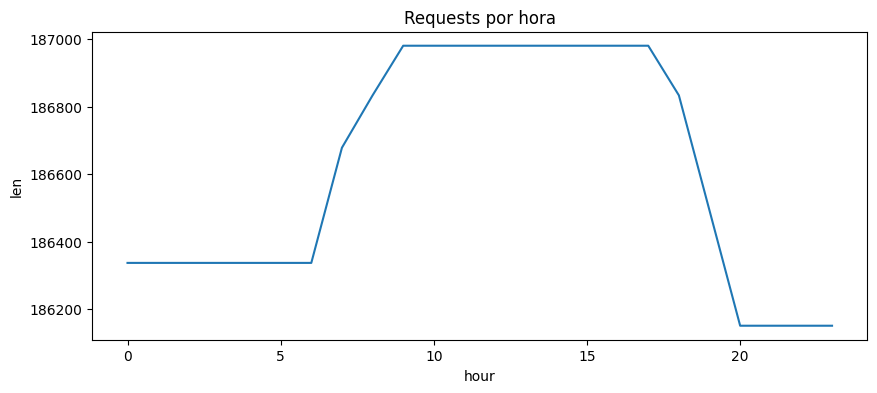

In [3]:
hourly=(events.with_columns(pl.col("timestamp").dt.hour().alias("hour"))
.group_by("hour").len().sort("hour").to_pandas())
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly,x="hour",y="len")
plt.title("Requests por hora")
plt.show()

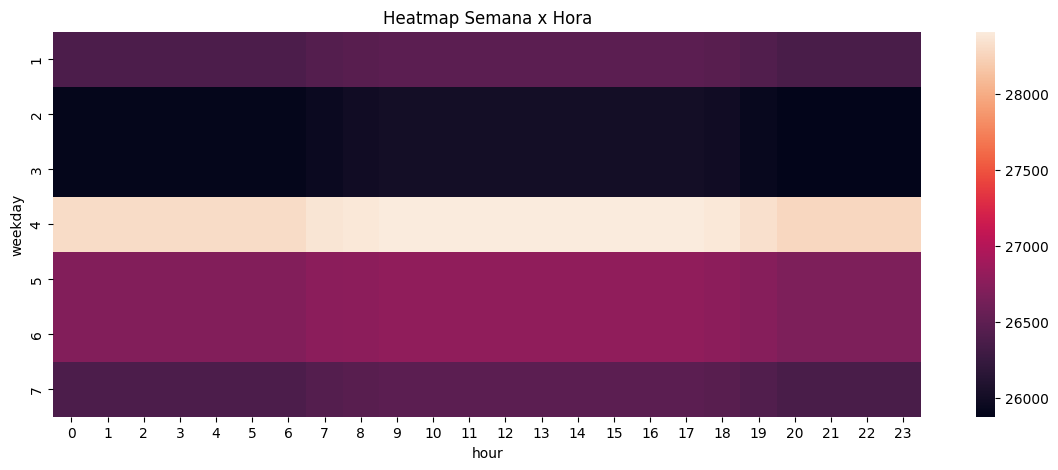

In [4]:
heat=(events.with_columns([
pl.col("timestamp").dt.weekday().alias("weekday"),
pl.col("timestamp").dt.hour().alias("hour")])
.group_by(["weekday","hour"]).len().to_pandas())
pivot=heat.pivot(index="weekday",columns="hour",values="len")
plt.figure(figsize=(14,5))
sns.heatmap(pivot)
plt.title("Heatmap Semana x Hora")
plt.show()